In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:
z_list = [5, 4, 3, 2, 1.5,1,  0.4, 0.1, 0]
snap_list = [17, 21, 25,33, 40, 50, 72,91, 99]

In [6]:

odir = "../ps_data"
ratio_list = []
gal_list = []
group_list = []
for snapnum in snap_list:
    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
        Pk_mean_gal10 = pickle.load(f)
        Pk_gal10 = pickle.load(f)
        
        
    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
        Pk_mean_gal10 = pickle.load(f)
        Pk_sum10 = pickle.load(f)

    ratio = Pk_sum10["power"].real/Pk_gal10["power"].real
    ratio_list.append(ratio)
    gal_list.append(Pk_gal10["power"].real)
    group_list.append(Pk_sum10["power"].real)

In [7]:
gal_arr = np.array(gal_list)
group_arr = np.array(group_list)

In [8]:
diff_list = abs(gal_arr - group_arr)

In [9]:
percent_err = diff_list/gal_arr

5


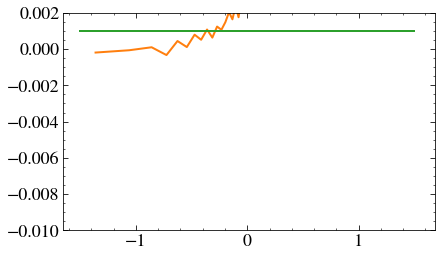

In [84]:
iz = -9

print(z_list[iz])
plt.plot([-1.5,1.5], [0.01,0.01])
plt.plot(np.log10(Pk_gal10["k"]), (group_list[iz]-gal_list[iz])/gal_list[iz])
plt.ylim(-0.01,0.002)
plt.plot([-1.5,1.5], [0.001,0.001])

(-0.01, 0.05)

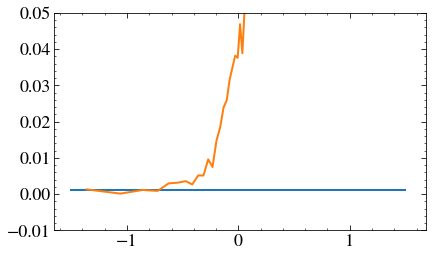

In [53]:


plt.plot(np.log10(Pk_gal10["k"]), percent_err[iz])
plt.ylim(-0.01,0.05)

(0.9, 1.1)

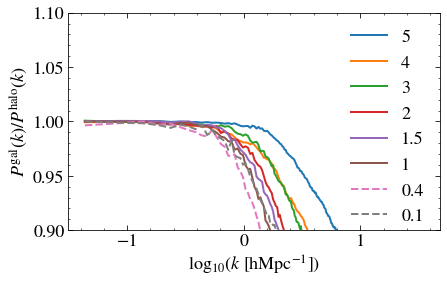

In [39]:
for i in range(6):
    plt.plot(np.log10(Pk_gal10["k"]), ratio_list[i], label=z_list[i])

for i in range(6,8):
    plt.plot(np.log10(Pk_gal10["k"]), ratio_list[i], label=z_list[i], linestyle="dashed")
plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$P^{\mathrm{gal}}(k)/P^{\mathrm{halo}}(k)$")
plt.ylim(0.9,1.1)

Text(0, 0.5, '$P^{\\mathrm{gal}}(k)/P^{\\mathrm{halo}}(k)$')

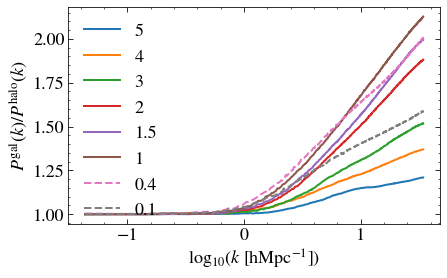

In [59]:
for i in range(6):
    plt.plot(np.log10(Pk_gal10["k"]), 1/ratio_list[i], label=z_list[i])

for i in range(6,8):
    plt.plot(np.log10(Pk_gal10["k"]), 1/ratio_list[i], label=z_list[i], linestyle="dashed")
plt.legend()
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$P^{\mathrm{gal}}(k)/P^{\mathrm{halo}}(k)$")

In [10]:
k01_list = []
k1_list = []
k5_list = []
k10_list = []
for i in range(9):
    mask = percent_err[i] < 0.001
    k01 = np.log10(Pk_gal10["k"])[mask][-1]
    mask = percent_err[i] < 0.01
    k1 = np.log10(Pk_gal10["k"])[mask][-1]
    mask = percent_err[i] < 0.05
    k5 = np.log10(Pk_gal10["k"])[mask][-1]
    mask = percent_err[i] < 0.1
    k10 = np.log10(Pk_gal10["k"])[mask][-1]
    
    k01_list.append(k01)
    k1_list.append(k1)
    k5_list.append(k5)
    k10_list.append(k10)
    

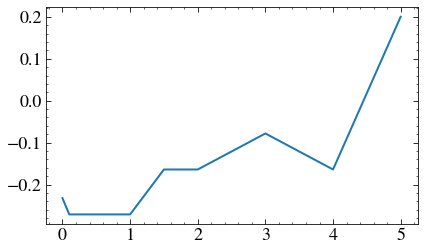

In [35]:
plt.plot(z_list, k1_list)

Text(0, 0.5, 'z')

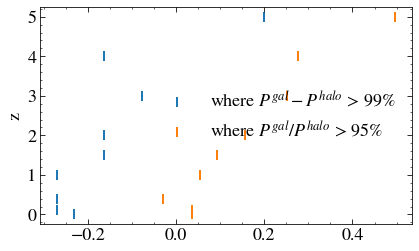

In [70]:
plt.scatter(k1_list, z_list, label="where $P^{gal}-P^{halo}$ > 99%", marker="|", s=100)
plt.scatter(k5_list, z_list, label="where $P^{gal}/P^{halo}$ > 95%", marker="|", s=100)
plt.legend()
plt.ylabel("z")


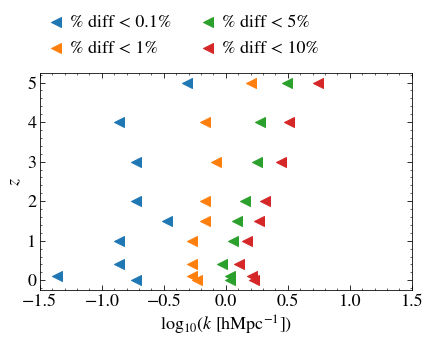

In [31]:
plt.scatter(k01_list, z_list, label="% diff < 0.1%", marker="<", s=100)

plt.scatter(k1_list, z_list, label="% diff < 1%", marker="<", s=100)
plt.scatter(k5_list, z_list, label="% diff < 5%", marker="<", s=100)

plt.scatter(k10_list, z_list, label="% diff < 10%", marker="<", s=100)

plt.ylabel("$z$")

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.xlim(-1.5,1.5)
plt.legend(handlelength=0, ncol=2, bbox_to_anchor=(0,1), loc="lower left")
#plt.savefig("../figures/gal_vs_group_logk.pdf", format="pdf", bbox_inches="tight")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB o

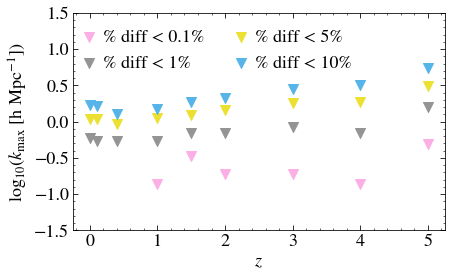

In [86]:
plt.scatter(z_list[:-3],k01_list[:-3],  label="% diff < 0.1%", marker="v", s=100, c=palette_tab10[6])

plt.scatter(z_list, k1_list, label="% diff < 1%", marker="v", s=100, c=palette_tab10[7])
plt.scatter(z_list, k5_list, label="% diff < 5%", marker="v", s=100, c=palette_tab10[8])

plt.scatter(z_list, k10_list, label="% diff < 10%", marker="v", s=100, c=palette_tab10[9])

plt.xlabel("$z$")

plt.ylabel(r"$\mathrm{log}_{10}(k_{\mathrm{max}}\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylim(-1.5,1.5)
plt.legend(handlelength=0, ncol=2, bbox_to_anchor=(0,1), loc="upper left")
#plt.savefig("../figures/gal_vs_group_logk.pdf", format="pdf", bbox_inches="tight")